Here I will try two ideas recommended to me by the mentors. 
- I will initialize my parameters to an already trained VAE instead of from scratch. For this I will try two things, first train my own separate VAE and second use a pretrained VAE on Cifar10 from the internet. 
- Then I will implement the joint training but using driftXpress

In [102]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
import torch.optim as optim
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [103]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    
    # Ensure deterministic behavior in PyTorch operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [104]:
def softmax(logits, dim):
    logits = logits - logits.max(dim=dim, keepdim=True).values
    exp = torch.exp(logits)
    return exp / exp.sum(dim=dim, keepdim=True)

def compute_V(y_neg, y_pos, T, eps=1e-8):
    N = y_neg.shape[0]
    points = torch.cat([y_neg, y_pos],dim=0).to(torch.float32)

    dist = torch.cdist(y_neg, points)
    dist[:, :N] += torch.eye(N, device=dist.device) * 1e6

    logits = -dist/T # this is log(k(x,y)) for every pair
    A_row = softmax(logits, dim=1)
    A_col = softmax(logits, dim=0)
    A = torch.sqrt(A_row * A_col)
    # A = A_row
    
    A_neg = A[:, :N]
    A_pos = A[:, N:]

    W_pos = A_pos * A_neg.sum(axis=1, keepdims=True)
    W_neg = A_neg * A_pos.sum(axis=1, keepdims=True)

    drift_pos = W_pos @ y_pos
    drift_neg = W_neg @ y_neg
    V = drift_pos - drift_neg
    
    return V

In [105]:
'''
def drift_loss(y_neg, y_pos, temp): 
    with torch.no_grad():
        V = compute_V(y_neg, y_pos, temp)
        frozen_targets = (y_neg + V).detach().clone()
    return mse(y_neg, frozen_targets), V
'''

def drift_loss(y_neg, y_pos, temp):
    with torch.no_grad():
        V = compute_V(y_neg, y_pos, temp)
        frozen_targets = y_neg.detach() + V

    per_sample_loss = (
        (y_neg - frozen_targets)
        .pow(2)
        .sum(dim=1)
    )

    return per_sample_loss.mean(), V
    
def recon_loss(y_pos_recon, y_pos):
    return F.mse_loss(y_pos_recon, y_pos, reduction='mean')



'''
def kl_loss(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
'''
def kl_loss(mu, logvar): # normalized
    kl_per_sample = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    ).sum(dim=-1)

    return kl_per_sample.mean()


# see VICReg
def variance_loss(mu, gamma=1.0, eps=1e-4):
    std = torch.sqrt(mu.var(dim=0, unbiased=True) + eps)
    return torch.mean(F.relu(gamma - std))

def covariance_loss(latents):
    batch_size, dim = latents.shape
    latents = latents - latents.mean(dim=0, keepdim=True)
    cov = (latents.T @ latents) / (batch_size - 1)   # bug fix: was `@ z`
    off_diag = cov - torch.diag(torch.diag(cov))
    return off_diag.pow(2).sum() / dim

def total_loss(y_pos_recon, y_pos, y_pos_mu, y_pos_logvar, y_neg_latent, y_pos_latent,temp,
                lambda_kl=0.01, lambda_drift=1.0, lambda_var=0.1, lambda_cov=0.1):
    L_recon = recon_loss(y_pos_recon, y_pos)
    L_kl    = kl_loss(y_pos_mu, y_pos_logvar)
    L_drift, V = drift_loss(y_neg_latent, y_pos_latent, temp)
    L_var   = variance_loss(y_pos_mu) + variance_loss(y_neg_latent)
    L_cov = covariance_loss(y_pos_mu) + covariance_loss(y_neg_latent)
    total = L_recon + lambda_kl*L_kl + lambda_drift*L_drift + lambda_var*L_var + lambda_cov*L_cov
    loss_items = {"recon": L_recon.detach(), "kl": L_kl.detach(),
                    "drift": L_drift.detach(), "V": V.detach(),"var": L_var.detach(), "covar":L_cov.detach()}
    return total, loss_items


In [106]:
import torch
import torch.nn as nn

class JointModel(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 48, 4, stride=2, padding=1),    # was 32
            nn.GroupNorm(8, 48), nn.LeakyReLU(0.2),
            nn.Conv2d(48, 96, 4, stride=2, padding=1),   # was 64
            nn.GroupNorm(8, 96), nn.LeakyReLU(0.2),
            nn.Conv2d(96, 192, 4, stride=2, padding=1),  # was 128
            nn.GroupNorm(8, 192), nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(192 * 4 * 4, latent_dim)
        self.fc_var = nn.Linear(192 * 4 * 4, latent_dim)

        # self.decoder_input = nn.Linear(latent_dim, 2048)
        self.decoder_input = nn.Linear(latent_dim, 384 * 4 * 4)   # widen to match
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(384, 192, 4, stride=2, padding=1),
            nn.GroupNorm(8, 192), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(192, 96, 4, stride=2, padding=1),
            nn.GroupNorm(8, 96), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(96, 48, 4, stride=2, padding=1),
            nn.GroupNorm(8, 48), nn.LeakyReLU(0.2),
            nn.Conv2d(48, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

        self.generator = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.SiLU(),
            nn.Linear(512, latent_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def get_latent(self, y):
        features = self.encoder(y)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        latent = self.reparameterize(mu, logvar)
        return mu, logvar, latent

    def decode(self, z):
        z = self.decoder_input(z)
        # z = z.view(z.size(0), 128, 4, 4)
        z = z.view(z.size(0),  384, 4, 4)
        return self.decoder(z)

    def generate(self, noise):
        generated_latent = self.generator(noise)
        generated_final = self.decode(generated_latent)
        return generated_latent, generated_final

C:\Users\mateo\AppData\Local\Temp\ipykernel_17936\3685442930.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


Total deer images extracted: 5000
Single sample shape: (32, 32, 3)
Data type: uint8


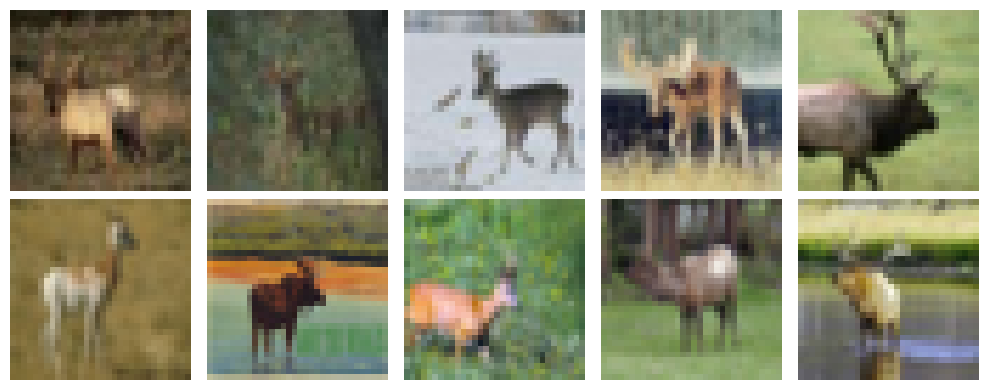

In [107]:
import pickle

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

all_deer_images = []

# Loop through all 5 training batches
for i in range(1, 6):
    batch = unpickle(f'../image_gen/cifar-10-batches-py/data_batch_{i}')
    
    raw_images = batch[b'data']
    labels = np.array(batch[b'labels'])
    
    # Filter indices where label is 4 (deer)
    # 0 is airplane
    deer_indices = np.where(labels == 4)[0]
    
    # Extract, reshape, and transpose those specific images
    filtered_images = raw_images[deer_indices].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    all_deer_images.append(filtered_images)

# Concatenate all batches into a single array
deer_dataset = np.concatenate(all_deer_images, axis=0)

print(f"Total deer images extracted: {deer_dataset.shape[0]}")
print("Single sample shape:", deer_dataset[0].shape)
print("Data type:", deer_dataset.dtype)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(deer_dataset[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [36]:
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader

deer_tensor = torch.from_numpy(deer_dataset).permute(0, 3, 1, 2).float() / 255.0
dataset = TensorDataset(deer_tensor)


loader = DataLoader(
    dataset, 
    batch_size=500, 
    shuffle=True, 
    drop_last=True, 
    num_workers=0,
    pin_memory=True       # Speeds up the transfer of data from CPU to GPU
)

In [108]:
def plot_direct_reconstructions(model, loader, num_images=5):
    """
    Plots real CIFAR-10 images directly next to their VAE reconstructions.
    Completely bypasses the noise sampling and drift generator.
    """
    model.eval() # Ensure dropout and batchnorm are in eval mode
    with torch.no_grad():
        # 1. Grab a single batch from your dataloader
        # Assuming your loader returns (images, labels) or just images
        batch = next(iter(loader))
        if isinstance(batch, list) or isinstance(batch, tuple):
            real_images = batch[0]
        else:
            real_images = batch
            
        real_images = real_images[:num_images].to(device)
        
        # 2. Push directly through the VAE (Encoder -> Decoder)
        mu, logvar, latent_z = model.get_latent(real_images)
        reconstructed_images = model.decode(latent_z)
        
        # 3. Format for Matplotlib (Move to CPU, reshape C,H,W to H,W,C)
        real_np = real_images.cpu().permute(0, 2, 3, 1).numpy()
        recon_np = reconstructed_images.cpu().permute(0, 2, 3, 1).numpy()
        
        # 4. Plot the comparison grid
        fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2.5, 5))
        fig.suptitle("Direct VAE Reconstructions (Top: Real | Bottom: Recon)", fontsize=16)
        
        for i in range(num_images):
            # Top row: Real Images
            axes[0, i].imshow(real_np[i])
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title("Real", fontweight='bold')
            
            # Bottom row: Reconstructed Images
            axes[1, i].imshow(recon_np[i])
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title("Recon", fontweight='bold')
                
        plt.tight_layout()
        plt.show()

In [109]:
def train_vae_only(num_epochs, real_loader, lambda_kl):
    model.train()
    losses = []
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for (real_x,) in real_loader:   # assuming you have a DataLoader; see note below
            real_x = real_x.to(device)
            optimizer.zero_grad()

            mu, logvar, z = model.get_latent(real_x)
            x_recon = model.decode(z)

            L_recon = F.mse_loss(x_recon, real_x, reduction='mean')
            L_kl = kl_loss(mu, logvar)
            loss = L_recon + lambda_kl * L_kl

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss / len(real_loader))
        if epoch % 10 == 0:
            print(f"epoch {epoch}: recon={L_recon.item():.4f} kl={lambda_kl * L_kl.item():.4f}")
    torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "latent_dim": model.latent_dim,
        "num_epochs": num_epochs,
    },
    "vae_pretrained.pt",
    )
    return model, losses
def training_loop(num_epochs, temp, lambda_kl, lambda_drift, lambda_var, lambda_cov, loader):
    model.to(device)
    train_losses = []
    recon_losses = []
    kl_losses = []
    drift_losses = []
    var_losses = []
    covar_losses = []
    average_V = []
    
    print("Training started")

    for epoch in range(num_epochs + 1):
        model.train()
        
        # Accumulators for the mini-batches
        epoch_loss = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0
        epoch_drift = 0.0
        epoch_var = 0.0
        epoch_covar = 0.0
        epoch_v = 0.0
        
        # Iterate over mini-batches
        for (truth,) in loader:
            truth = truth.to(device)
            curr_batch_size = truth.size(0)
            
            # Generate noise matching current batch size and latent dim
            noise = torch.randn(curr_batch_size, model.latent_dim, device=device)
            
            optimizer.zero_grad()

            # Forward passes
            mu, logvar, y_pos_latent = model.get_latent(truth)
            # y_pos_latent_detached = y_pos_latent.detach()   # drift sees this, but no gradient flows back into encoder from it
            y_pos_recon = model.decode(y_pos_latent)
            y_neg_latent, y_neg_recon = model.generate(noise)
            
            # Loss calculation
            loss, loss_items = total_loss(y_pos_recon, truth, mu, logvar, y_neg_latent, y_pos_latent, temp,
                                          lambda_kl, lambda_drift, lambda_var, lambda_cov)
            loss.backward()
            optimizer.step()
            
            # Accumulate metrics
            epoch_loss += loss.item()
            epoch_recon += loss_items["recon"].item()
            epoch_kl += loss_items["kl"].item() * lambda_kl
            epoch_drift += loss_items["drift"].item() * lambda_drift
            epoch_var += loss_items["var"].item() * lambda_var
            epoch_covar += loss_items["covar"].item() * lambda_cov
            epoch_v += loss_items["V"].norm(dim=1).mean().item()
            
        # Average the accumulated losses over the number of batches
        num_batches = len(loader)
        avg_epoch_loss = epoch_loss / num_batches
        avg_items = {
            "recon": epoch_recon / num_batches,
            "kl": epoch_kl / num_batches,  # Already scaled above
            "drift": epoch_drift / num_batches, # Already scaled above
            "var": epoch_var / num_batches, # Already scaled above
            "covar": epoch_covar / num_batches, # Already scaled above
            "V_mag": epoch_v / num_batches
        }

        scheduler.step()
        
        # Append to histories
        train_losses.append(avg_epoch_loss)
        recon_losses.append(avg_items["recon"])
        kl_losses.append(avg_items["kl"])
        drift_losses.append(avg_items["drift"])
        var_losses.append(avg_items["var"])
        covar_losses.append(avg_items["covar"])
        average_V.append(avg_items["V_mag"])
        
        
        if epoch < 20 or epoch % 50 == 0:
            print(f"-------- Epoch {epoch}--------")
            print(f"Loss summary:")
            print(f"total={avg_epoch_loss:.4f}\n")
            print("Loss composition")
            print(f"Recon {avg_items['recon'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Kl (scaled) {avg_items['kl'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Drift (scaled) {avg_items['drift'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Var (scaled) {avg_items['var'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Covar (scaled) {avg_items['covar'] * 100 / avg_epoch_loss:.2f}%\n")
            
            print(f"recon loss: {avg_items['recon']:.10f}")
            print(f"kl loss scaled: {avg_items['kl']:.10f}")
            print(f"drift loss scaled: {avg_items['drift']:.10f}")
            print(f"var loss scaled: {avg_items['var']:.10f}")
            print(f"covar loss scaled: {avg_items['covar']:.10f}")
            print("Average force magnitude across all points (V): ", avg_items["V_mag"])
            
            # Stats computed on the final batch of the epoch
            print("distances (last batch):", torch.cdist(y_pos_latent[:50], y_pos_latent[:50]).mean().item())
            print("y_neg spread (last batch):", y_neg_latent.std(dim=0).mean().item())
            print("y_pos spread (last batch):", y_pos_latent.std(dim=0).mean().item())
            print()
            
    print("Finished")
    torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "num_epochs": num_epochs,
    },
    "vae_joint_pure_drift.pt",)
    return model, train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V

In [110]:
model = JointModel(latent_dim=100).to(device)
# mse = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 1000
model, losses = train_vae_only(num_epochs, loader, lambda_kl=0)

epoch 0: recon=0.0453 kl=0.0000
epoch 10: recon=0.0138 kl=0.0000
epoch 20: recon=0.0098 kl=0.0000
epoch 30: recon=0.0085 kl=0.0000
epoch 40: recon=0.0077 kl=0.0000
epoch 50: recon=0.0066 kl=0.0000
epoch 60: recon=0.0060 kl=0.0000
epoch 70: recon=0.0056 kl=0.0000
epoch 80: recon=0.0054 kl=0.0000
epoch 90: recon=0.0055 kl=0.0000
epoch 100: recon=0.0050 kl=0.0000
epoch 110: recon=0.0050 kl=0.0000
epoch 120: recon=0.0049 kl=0.0000
epoch 130: recon=0.0049 kl=0.0000
epoch 140: recon=0.0048 kl=0.0000
epoch 150: recon=0.0046 kl=0.0000
epoch 160: recon=0.0046 kl=0.0000
epoch 170: recon=0.0046 kl=0.0000
epoch 180: recon=0.0044 kl=0.0000
epoch 190: recon=0.0045 kl=0.0000
epoch 200: recon=0.0044 kl=0.0000
epoch 210: recon=0.0044 kl=0.0000
epoch 220: recon=0.0043 kl=0.0000
epoch 230: recon=0.0043 kl=0.0000
epoch 240: recon=0.0044 kl=0.0000
epoch 250: recon=0.0042 kl=0.0000
epoch 260: recon=0.0042 kl=0.0000
epoch 270: recon=0.0042 kl=0.0000
epoch 280: recon=0.0040 kl=0.0000
epoch 290: recon=0.0041 k

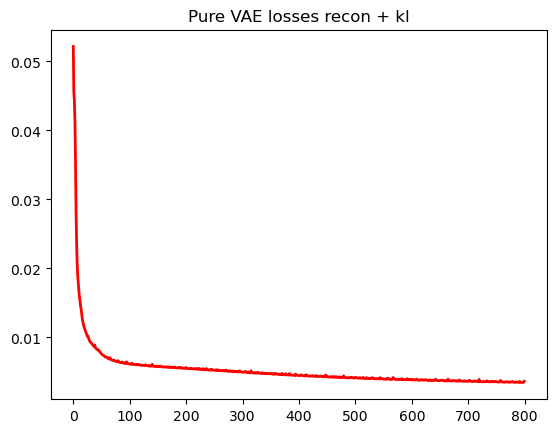

In [91]:
plt.plot(losses, color='red', linewidth=2)
plt.title("Pure VAE losses recon + kl")
plt.show()

In [94]:
model.eval()

with torch.no_grad():
    real_images = next(iter(loader))[0][:6].to(device)

    mu, logvar, z = model.get_latent(real_images)

    recon_mu = model.decode(mu)
    recon_z = model.decode(z)

    print("mean posterior std:", torch.exp(0.5 * logvar).mean().item())
    print("median posterior std:", torch.exp(0.5 * logvar).median().item())
    print("MSE from mu:", F.mse_loss(recon_mu, real_images).item())
    print("MSE from sampled z:", F.mse_loss(recon_z, real_images).item())

mean posterior std: 0.00013634619244839996
median posterior std: 0.00013195580686442554
MSE from mu: 0.0031647745054215193
MSE from sampled z: 0.0031649458687752485


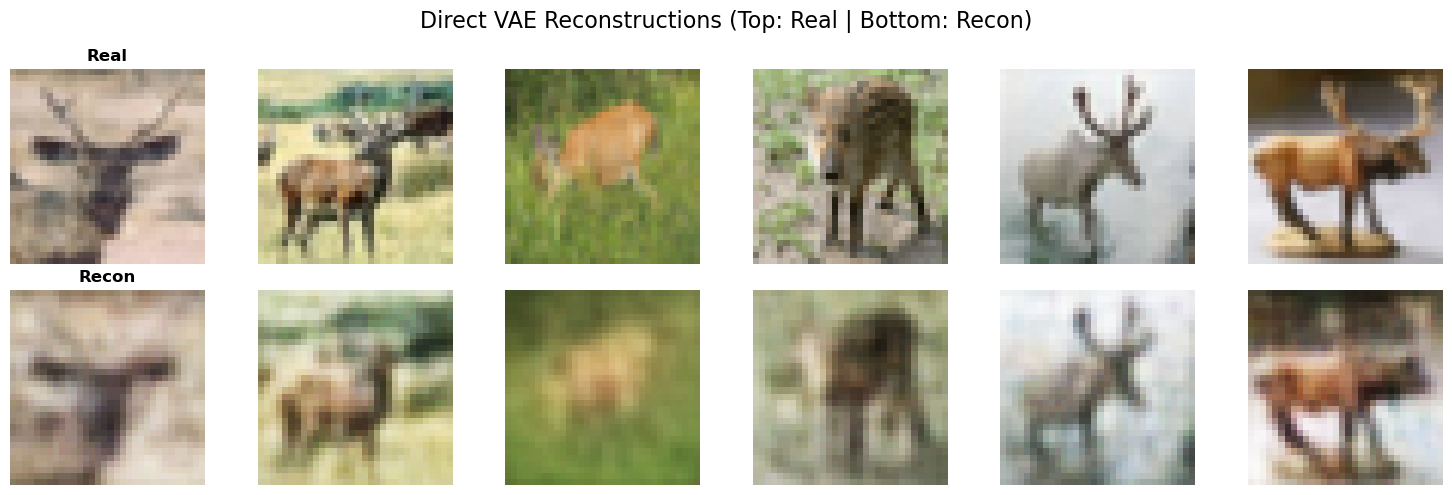

In [93]:
plot_direct_reconstructions(model, loader, num_images=6)

In [63]:
num_epochs = 2500

optimizer = optim.AdamW(model.parameters(), lr=0.0003)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-5,
)

temp = 22
lambda_kl = 1e-6
lambda_var = 1.0
lambda_cov = 1.0
lambda_drift = 1.0

model, train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V = training_loop(
    num_epochs=num_epochs,
    temp=temp,
    lambda_kl=lambda_kl,
    lambda_drift=lambda_drift,
    lambda_var=lambda_var,
    lambda_cov=lambda_cov,
    loader=loader,
)


Training started
-------- Epoch 0--------
Loss summary:
total=2.5494

Loss composition
Recon 1.27%
Kl (scaled) 0.06%
Drift (scaled) 51.06%
Var (scaled) 41.30%
Covar (scaled) 6.31%

recon loss: 0.0323374931
kl loss scaled: 0.0015054344
drift loss scaled: 1.3016865790
var loss scaled: 1.0529283702
covar loss scaled: 0.1609323587
Average force magnitude across all points (V):  1.1213552892208098
distances (last batch): 10.949396133422852
y_neg spread (last batch): 0.0584108829498291
y_pos spread (last batch): 0.9515001177787781

-------- Epoch 1--------
Loss summary:
total=2.1423

Loss composition
Recon 0.82%
Kl (scaled) 0.07%
Drift (scaled) 46.56%
Var (scaled) 45.03%
Covar (scaled) 7.52%

recon loss: 0.0174739862
kl loss scaled: 0.0014100979
drift loss scaled: 0.9975352764
var loss scaled: 0.9647629619
covar loss scaled: 0.1611530185
Average force magnitude across all points (V):  0.9804976761341095
distances (last batch): 10.906112670898438
y_neg spread (last batch): 0.07352649420499802

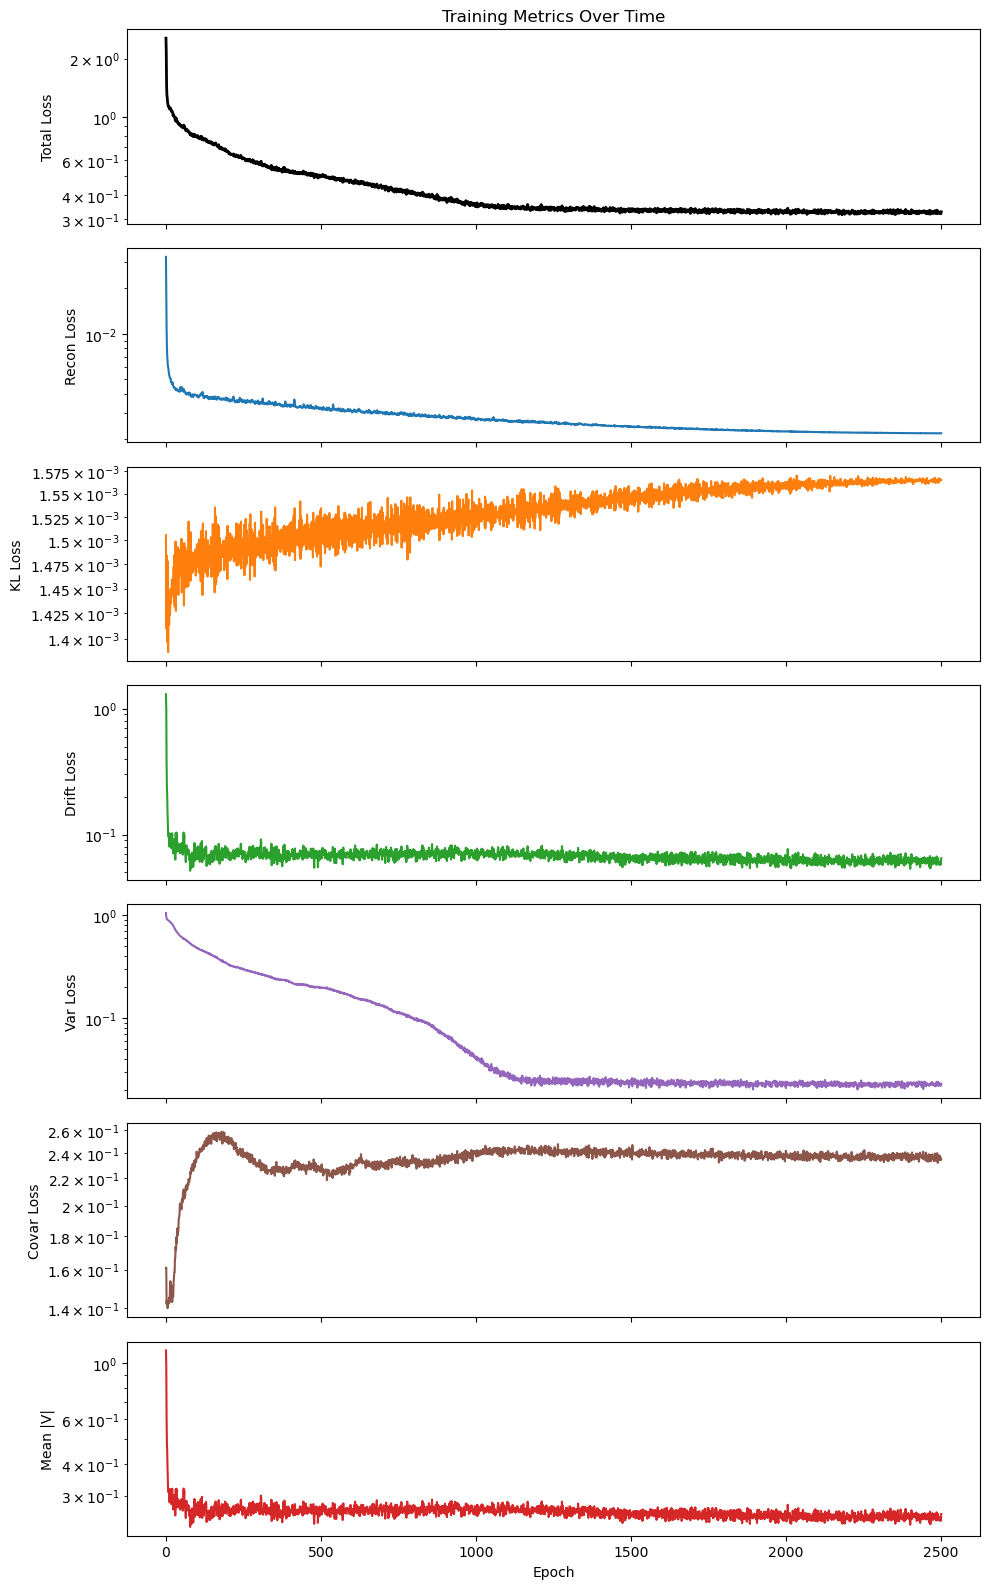

In [64]:
def to_float_list(data_list):
    return [x.item() if hasattr(x, 'item') else x for x in data_list]

train_losses = to_float_list(train_losses)
recon_losses = to_float_list(recon_losses)
kl_losses = to_float_list(kl_losses)
drift_losses = to_float_list(drift_losses)
var_losses = to_float_list(var_losses)
covar_losses = to_float_list(covar_losses)
average_V = to_float_list(average_V)

# 3. Create 7 separate subplots stacked vertically
# We increase the figure height (e.g., 16) so they aren't squished
fig, axes = plt.subplots(7, 1, figsize=(10, 16), sharex=True)

# Total Loss
axes[0].plot(train_losses, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Metrics Over Time')

# Recon Loss
axes[1].plot(recon_losses, color='tab:blue')
axes[1].set_yscale('log')
axes[1].set_ylabel('Recon Loss')

# KL Loss
axes[2].plot(kl_losses, color='tab:orange')
axes[2].set_yscale('log')
axes[2].set_ylabel('KL Loss')

# Drift Loss
axes[3].plot(drift_losses, color='tab:green')
axes[3].set_yscale('log')
axes[3].set_ylabel('Drift Loss')

# Var Loss
axes[4].plot(var_losses, color='tab:purple')
axes[4].set_yscale('log')
axes[4].set_ylabel('Var Loss')

# Covar Loss
axes[5].plot(covar_losses, color='tab:brown')
axes[5].set_yscale('log')
axes[5].set_ylabel('Covar Loss')

# Average V (Drift Field Magnitude)
axes[6].plot(average_V, color='tab:red')
axes[6].set_yscale('log')
axes[6].set_ylabel('Mean |V|')
axes[6].set_xlabel('Epoch') # Only need x-label on the very bottom graph

plt.tight_layout()
plt.show()

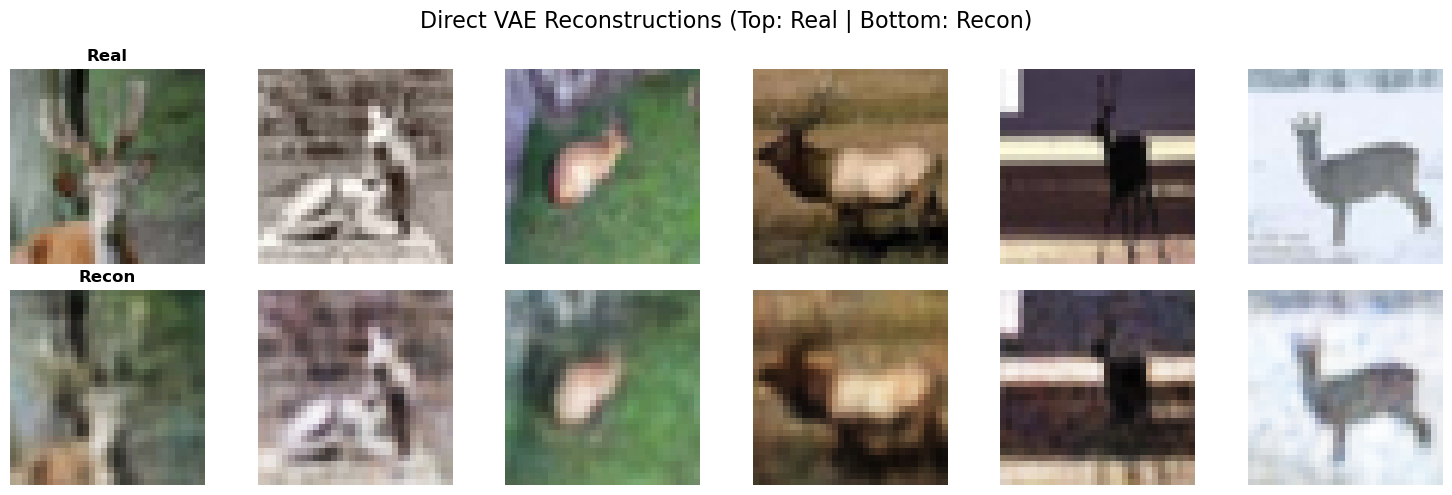

In [65]:
plot_direct_reconstructions(model, loader, num_images=6)

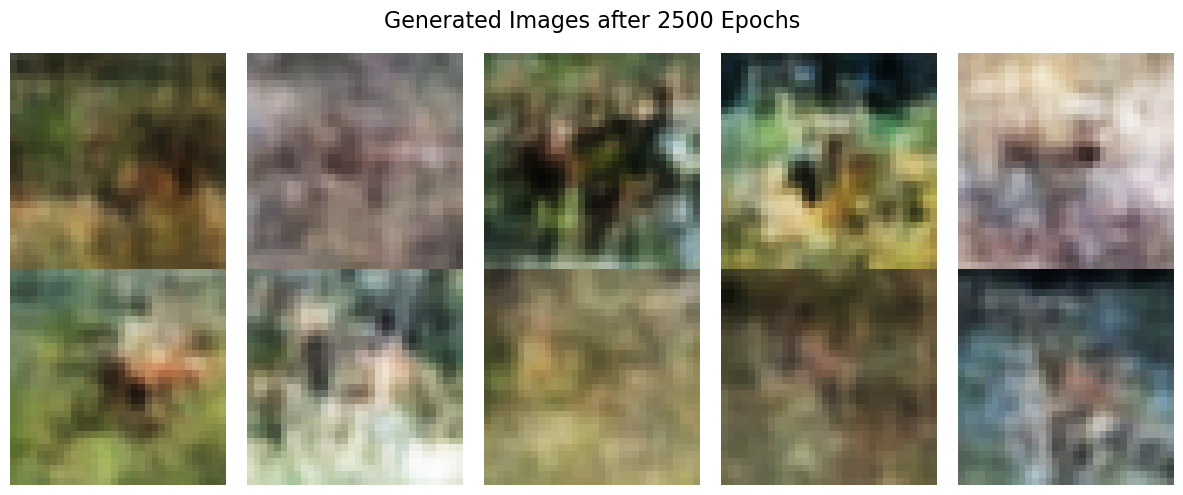

In [68]:
model.eval()
with torch.no_grad():
    # Sample random noise for 10 new images (Batch, Latent_Dim)
    sample_noise = torch.randn(10, model.latent_dim, device=device)
    
    # Generate the images purely from the noise
    _, generated_images = model.generate(sample_noise)
    
    # Move to CPU, reshape from (N, C, H, W) to (N, H, W, C) for Matplotlib
    generated_images = generated_images.cpu().permute(0, 2, 3, 1).numpy()

    # Plot the grid
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f"Generated Images after {num_epochs} Epochs", fontsize=16)
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()